# **Line Chart**

In [ ]:
# Import Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [4]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

df_DA_exploded = df_DA.explode('job_skills')

df_DA_pivot = df_DA_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

In [5]:
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_pivot = df_DA_pivot.drop('Total')

df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,angular.js,xamarin,gtx,nuxt.js,ovh,esquisse,suse,capacitor,chainer,msaccess
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,2,0,0,1,0,0,0,1,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,0,1,0,0,0,0,1,0,0,0
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,1,0,0,0,0,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,0,0,1
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns=['job_posted_month_no'])

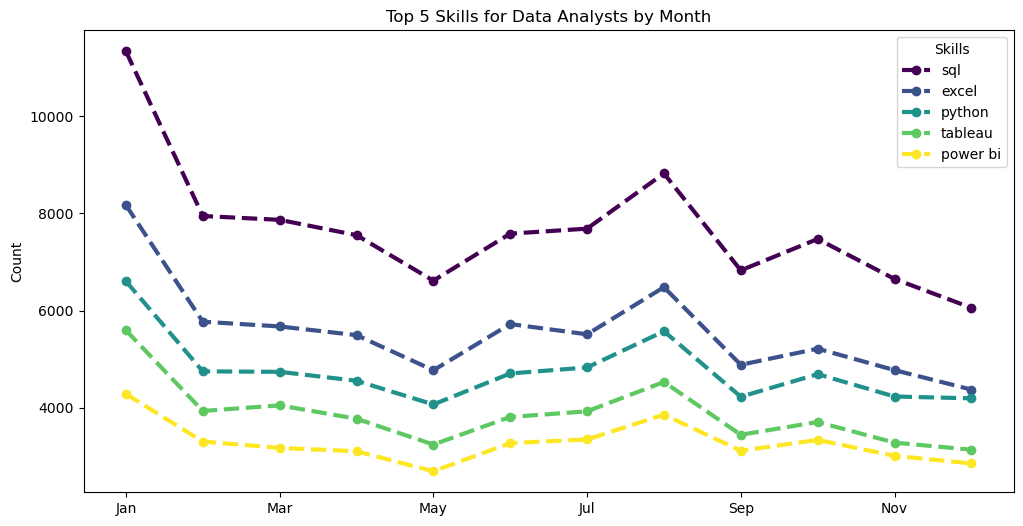

In [ ]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line', # 'bar', 'hist', 'box', 'area', 'pie', 'scatter', 'hexbin', 'barh', 'kde', 'density', 'hexbin',...
    linewidth='3',
    linestyle='--', # ':', '-.', '-', ...
    colormap='viridis', # 'cm', 'plasma', 'inferno', 'magma', 'cividis', ...
    marker='o', # 'o', 's', '^', 'D', 'v', 'P', '*', ...
    figsize=(12, 6)
    
    )
plt.xlabel('')
plt.ylabel('Count')
plt.title('Top 5 Skills for Data Analysts by Month')
plt.legend(title='Skills')
plt.show()

# **Scatter Plot**

In [14]:
df = df[df['job_title_short'] == 'Data Analyst'].copy()

df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(20)

skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


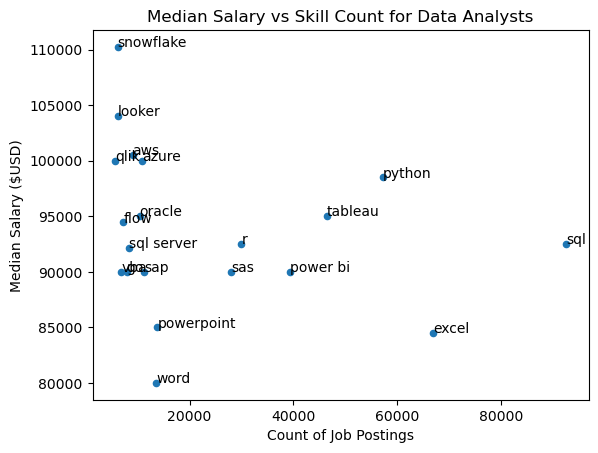

In [15]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.title('Median Salary vs Skill Count for Data Analysts')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary ($USD)')

for i, skill in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], skill)
    # plt.annotate(skill, (skill_stats['skill_count'][i], skill_stats['median_salary'][i]))
plt.show()

In [16]:
from adjustText import adjust_text

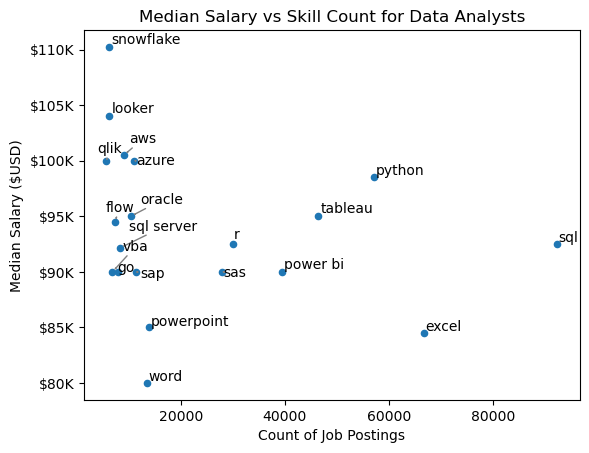

In [29]:
#fig, ax = plt.subplots()

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

texts = []
for i, skill in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], skill))
    # plt.annotate(skill, (skill_stats['skill_count'][i], skill_stats['median_salary'][i]))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

plt.title('Median Salary vs Skill Count for Data Analysts')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary ($USD)')
plt.show()